# A Quick Recap for the each part of the AI agents field


##  LangChain vs LangGraph State & Component Comparison

This document summarizes the key concepts discussed: **LangChain**, **LangGraph**, **AgentState**, **TypedDict State**, **dataclass Context**, and **Pydantic BaseModel**.

---

### 1. High-Level Architecture

| Layer | Purpose | Typical Components | Who Owns It |
|------|---------|-------------------|-------------|
| Capability Layer | Provides AI functionality | LLMs, Tools, Prompts | LangChain |
| Execution Layer | Controls flow of execution | Graph nodes, edges, reducers | LangGraph |
| Agent Memory | Stores agent reasoning state | AgentState | LangChain |
| Workflow State | Data passed between steps | TypedDict State | LangGraph |
| Runtime Context | External configuration | dataclass context | Application |
| Data Contracts | Validate structured input/output | Pydantic BaseModel | Tools / APIs |

---

### 2. LangChain vs LangGraph

| Feature | LangChain | LangGraph |
|-------|-----------|-----------|
| Primary Role | AI capability framework | Execution orchestration |
| Core Concept | Agents | Graph workflows |
| Control Flow | Implicit agent loop | Explicit graph |
| State Management | Agent memory | Workflow state |
| Parallel Execution | Limited | Native |
| Determinism | Lower | High |
| Production Workflows | Harder to manage | Designed for production |
| Tooling | LLMs, prompts, tools | Nodes, edges, reducers |
| Interrupt Support | Agent-level | Graph-level |
| Checkpointing | Limited | Built-in |

---

### 3. AgentState vs TypedDict State

| Aspect | AgentState | TypedDict State |
|------|-------------|----------------|
| Library | LangChain | LangGraph |
| Purpose | Agent internal memory | Workflow shared state |
| Structure | Python class | Dictionary schema |
| Mutation Style | Mutable object | Functional updates |
| Scope | Single agent | Entire workflow |
| Supports Reducers | No | Yes |
| Parallel Updates | No | Yes |
| Context Growth | Continuous | Controlled |
| Used By | Tools, middleware | Graph nodes |
| Control Flow | Agent loop | Graph edges |

---

### 4. dataclass Context vs AgentState

| Aspect | dataclass Context | AgentState |
|------|------------------|-----------|
| Purpose | Runtime configuration | Agent memory |
| Mutability | Typically static | Mutable |
| Lifecycle | Provided at invocation | Changes during execution |
| Storage | Outside the agent | Inside the agent |
| Example Data | API keys, user info | authentication flags |
| Persistence | No | Optional |
| Context Window Impact | None | Yes |


### 5. TypedDict vs BaseModel

| Aspect | TypedDict | BaseModel |
|------|------------------|-----------|
| Library | Python typing | Pydantic |
| Purpose | Describe dictionary structure | Validate structured data |
| Runtime Validation | No | Yes |
| Used In | Graph state |Tools / APIs |
| Serialization | Manual | Automatic |
| Strict Typing | Static only | Runtime enforcedOptional |
| Ideal For | Workflow data flow | API schemas  |



### 6. State Evolution Comparison

| Property        | AgentState          | TypedDict         |
| --------------- | ------------------- | ----------------- |
| Memory Pattern  | Accumulating memory | Selective updates |
| Context Size    | Grows continuously  | Controlled        |
| Data Ownership  | Agent               | Workflow          |
| Update Method   | Attribute mutation  | Return dictionary |
| Parallel Safety | No                  | Yes               |


### 7. Mental Model Summary

| Concept           | Think of it as                       |
| ----------------- | ------------------------------------ |
| LangChain         | AI capability toolkit                |
| LangGraph         | Workflow execution engine            |
| AgentState        | What the agent remembers             |
| TypedDict State   | Data flowing through the workflow    |
| dataclass Context | Configuration provided to the system |
| BaseModel         | Contract enforcing structured data   |


### 8. Final Simplified Architecture Diagram
```text
Application
   |
   |-- Context (dataclass)
   |
LangGraph Workflow
   |
   |-- State (TypedDict)
   |
   |-- Node
        |
        |-- LangChain Agent
                |
                |-- AgentState
                |-- Tools
                |-- LLM
```

# RAG From Scratch: Advanced Indexing

Explores advanced indexing strategies that go beyond simple chunk-and-embed. This notebook covers **Multi-Representation Indexing** — storing summaries in the vector store for retrieval while keeping raw documents in a separate docstore for generation.

**Prerequisites**: Run the environment setup and indexing cells from previous notebooks first. Chunking (the pre-phase of indexing) is covered in the [Part 1-4 notebook](../part_1_4/part_1_4.ipynb).

In [1]:
import warnings
import os 
from dotenv import load_dotenv

# Suppress all warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Load environment variables from the .env file into the process
load_dotenv()

try: 
    # Map .env variables to the keys LangChain/LangSmith expects at runtime
    os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGSMITH_TRACING_V2")   # Enable LangSmith tracing
    os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")         # LangSmith authentication key
    os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")         # LangSmith project name for grouping traces
    os.environ["LANGCHAIN_ENDPOINT"] = os.getenv("LANGSMITH_ENDPOINT")       # LangSmith API endpoint URL
    os.environ["MISTRAL_API_KEY"] = os.getenv("MISTRAL_API_KEY")             # Mistral AI LLM/embedding API key
    os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")                           # HuggingFace access token
    os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")               # Google Generative AI API key
    os.environ["OPEN_ROUTER_API_KEY"] = os.getenv("OPEN_ROUTER_API_KEY")     # OpenRouter API key
    os.environ["USER_AGENT"] = "MyLangChainApp/1.0"                           # Required User-Agent header for WebBaseLoader
    print("Environment variables set successfully")
except Exception as e: 
    print(f"Error: {e}")

Environment variables set successfully


### Environment Initialization

Loads `.env` variables for LangSmith tracing, Mistral API, HuggingFace token, and User-Agent. Suppresses warnings.

### Part 12: Multi-Representation Indexing

Stores **summaries** in the vector store and **raw documents** in a docstore, linked by `doc_id`. During retrieval, summaries are matched via similarity search, then the corresponding full documents are fetched from the docstore for generation.

This approach gives the best of both worlds: concise summaries improve retrieval precision, while full documents provide complete context for the LLM.

The process is to take a document, create a summary of it, and then use that summary to answer questions about the document.
Whereas the raw the document is stored in the docstore, the summary is stored in the vector store to be used for similarity search with the user 
query, then retrieve the relevant documents and use them to answer the user query.

and you can see it more detailed in the following diagram: 

```text
┌─────────────────────────────────────────────────────────┐
│                    INDEXING PHASE                       │
│                                                         │
│  Raw Doc ──► Summarize ──► Store Summary in Vectorstore │
│     │                                                   │
│     └──────────────────► Store Raw Doc in Docstore      │
│                          (linked by same doc_id)        │
└─────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────┐
│                    RETRIEVAL PHASE                      │
│                                                         │
│  User Query ──► Similarity Search on Summaries          │
│                        │                                │
│                        ▼                                │
│               Find matching doc_id                      │
│                        │                                │
│                        ▼                                │
│               Fetch Raw Doc from Docstore               │
│                        │                                │
│                        ▼                                │
│               Return Raw Doc to LLM                     │
└─────────────────────────────────────────────────────────┘
```

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Load the first blog post (LLM-powered agents)
loader = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/")
docs = loader.load()

# Load the second blog post (human data quality) and append to the same list
loader = WebBaseLoader("https://lilianweng.github.io/posts/2024-02-05-human-data-quality/")
docs.extend(loader.load())  # Now docs contains 2 full Document objects

#### Load Source Documents

Fetches two blog posts using `WebBaseLoader`:
1. Lilian Weng's post on LLM-powered agents.
2. Lilian Weng's post on human data quality.

Both are loaded as full `Document` objects and combined into a single list.

In [3]:
# Inspect metadata of the first document (source URL, title, etc.)
# Uncomment the line below to see the full page content:
# docs[0].page_content
docs[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

#### Generate Summaries

Uses a summarization chain (`ChatMistralAI` with `mistral-medium-latest`) to produce concise summaries of each document. `chain.batch()` processes both documents in parallel with `max_concurrency=5`.

In [4]:
import uuid

from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_mistralai import ChatMistralAI

# Summarization chain: extract page_content → summarize with LLM → parse to string
chain = (
    {"doc": lambda x: x.page_content}                                            # Extract the document text
    | ChatPromptTemplate.from_template("Summarize the following document: \n\n{doc}")  # Summarization prompt
    | ChatMistralAI(model="mistral-medium-latest", max_retries=0)                 # Generate summary
    | StrOutputParser()                                                            # Parse LLM output to string
)

# Process both documents in parallel (max_concurrency=5)
summaries = chain.batch(docs, {"max_concurrency": 5})

#### Set Up MultiVectorRetriever

Creates the dual-store architecture:
- **Vector store** (`Chroma`, `"summaries"` collection) — Stores summary embeddings for similarity search.
- **Byte store** (`InMemoryByteStore`) — Stores raw documents keyed by `doc_id`.
- **`MultiVectorRetriever`** — Links both stores; searches summaries, returns raw docs.

Each summary `Document` is tagged with a `doc_id` that maps to the corresponding raw document in the byte store. Both stores are populated via `add_documents()` and `mset()`.

In [5]:
from langchain_core.stores import InMemoryByteStore
from langchain_mistralai import MistralAIEmbeddings
from langchain_chroma import Chroma
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

# ==========================
# Vector Store: stores summary embeddings for similarity search
# ==========================
vectorstore = Chroma(
    collection_name = "summaries",                  # Collection name for summary embeddings
    embedding_function = MistralAIEmbeddings(),     # Mistral embedding model
    persist_directory = "./chroma_db",              # Persist in the current directory
)

# ==========================
# Byte Store: stores raw (full) documents keyed by doc_id
# ==========================
store = InMemoryByteStore()     # In-memory key-value store for raw documents
id_key = "doc_id"               # Metadata key that links summaries to raw docs

# ==========================
# MultiVectorRetriever: searches summaries, returns raw documents
# ==========================
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,    # Searches against summary embeddings
    byte_store=store,           # Fetches raw documents by doc_id
    id_key=id_key,              # The metadata key used to link both stores
)

# Generate unique IDs for each raw document
doc_ids = [str(uuid.uuid4()) for _ in docs]

# Create summary Documents tagged with their corresponding doc_id
summary_docs = [
    Document(page_content=s, metadata={id_key: doc_ids[i]})
    for i, s in enumerate(summaries)
]

# Populate the vector store with summary embeddings
retriever.vectorstore.add_documents(summary_docs)

# Populate the byte store with raw documents (linked by doc_id)
retriever.docstore.mset(list(zip(doc_ids, docs)))

#### Test: Similarity Search on Summaries

Runs a direct similarity search on the vector store with the query *"Memory in Agents"*. Returns the matched **summary** document (not the raw document). This confirms the summaries are properly indexed.

In [6]:
# Test: direct similarity search on the vector store (returns SUMMARY documents)
query = "Memory in Agents"
sub_docs = vectorstore.similarity_search(query, k=1)  # Top-1 most similar summary
sub_docs  # This returns the summary, NOT the raw document

[Document(id='46d6fddc-abb9-4248-828f-34c0c53030ec', metadata={'doc_id': 'ad807c0a-d479-420f-9b84-8e160b97b0c6'}, page_content='### **Summary of *LLM Powered Autonomous Agents* by Lilian Weng**\n\nThis article explores the concept of **LLM-powered autonomous agents**, where large language models (LLMs) act as the "brain" of agents capable of planning, memory, and tool use. The post discusses key components, case studies, challenges, and proof-of-concept examples.\n\n---\n\n### **1. Agent System Overview**\nAn LLM-powered autonomous agent consists of three core components:\n- **Planning**: Breaking tasks into subgoals and refining actions via self-reflection.\n- **Memory**: Short-term (in-context learning) and long-term (external vector stores for retrieval).\n- **Tool Use**: Calling external APIs for real-time data, computations, or proprietary knowledge.\n\n---\n\n### **2. Component One: Planning**\n#### **Task Decomposition**\n- **Chain of Thought (CoT)**: Encourages step-by-step rea

#### Test: Full Retrieval via MultiVectorRetriever

Invokes the `MultiVectorRetriever` with the same query. Unlike direct similarity search, this returns the **full raw document** from the byte store (linked by `doc_id`). Prints the first 500 characters to verify the raw content.

In [7]:
# Test: full retrieval via MultiVectorRetriever (returns RAW documents from byte store)
# The retriever searches summaries, finds the matching doc_id, then fetches the full raw doc
retrieved_docs = retriever.invoke(query, n_results = 1)

# Preview the first 500 characters of the raw document to verify it's the full content
retrieved_docs[0].page_content[0:500]

"\n\n\n\n\n\nLLM Powered Autonomous Agents | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three:"

### Part 13: RAPTOR

**RAPTOR** (Recursive Abstractive Processing for Tree-Organized Retrieval) builds a hierarchical tree of document summaries at multiple levels of abstraction. This enables retrieval at different granularities — from fine-grained chunks to high-level topic summaries.



The [`RAPTOR`](https://arxiv.org/pdf/2401.18059) paper presents an interesting approaching for indexing and retrieval of documents:

- The `leafs` are a set of starting documents
- Leafs are embedded and clustered
- Clusters are then summarized into higher level (more abstract) consolidations of information across similar documents


This process is done recursivly, resulting in a "tree" going from raw docs (leafs) to more abstract summaries.

We can applying this at varying scales; `leafs` can be:
- Text chunks from a single doc (as shown in the paper)
- Full docs (as we show below)

With longer context LLMs, it's possible to perform this over full documents.


![alt text](../../assets/RAPTOR.png)

#### Docs
Let's apply this to LangChain's LCEL documentation.

In this case, each `doc` is a unique web page of the LCEL docs.

The context varies from < 2k tokens on up to > 10k tokens.

<function matplotlib.pyplot.show(close=None, block=None)>

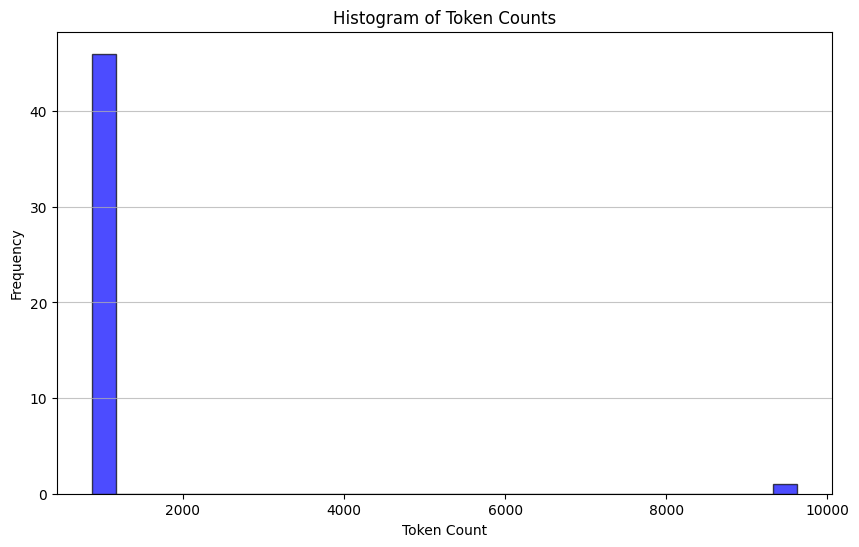

In [8]:
import matplotlib.pyplot as plt
import tiktoken
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader

# NOTE: This function is identical to the one in part_1_4.ipynb (Part 2: Indexing)
def num_tokens_from_string(string: str, encoding_name: str) -> int: 
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# ==========================
# Load LCEL Documentation Pages
# ==========================

# Primary LCEL docs — recursively crawl up to 20 levels deep
url = "https://python.langchain.com/docs/expression_language/"
loader_1 = RecursiveUrlLoader(
    url = url,
    max_depth = 20,                                        # Deep crawl to capture all subpages
    extractor = lambda x: Soup(x, "html.parser").text      # Strip HTML, keep plain text
)
docs = loader_1.load()

# Additional LCEL-related page: PydanticOutputParser (outside primary LCEL docs tree)
url = "https://python.langchain.com/docs/modules/model_io/output_parsers/quick_start"
loader_2 = RecursiveUrlLoader(
    url = url,
    max_depth = 1,                                         # Only this page, no deeper crawl
    extractor = lambda x: Soup(x, "html.parser").text
)
docs_pydantic = loader_2.load()

# Additional LCEL-related page: Self-Query retriever
url = "https://python.langchain.com/docs/modules/data_connection/retrievers/self_query/"
loader_3 = RecursiveUrlLoader(
    url = url,
    max_depth = 1,
    extractor = lambda x: Soup(x, "html.parser").text
)
docs_sq = loader_3.load()

# Combine all loaded documents into a single list and extract text content
docs.extend([*docs_pydantic, *docs_sq])
docs_texts = [d.page_content for d in docs]

# ==========================
# Visualize Token Distribution
# ==========================

# Count tokens per document using cl100k_base encoding (GPT-4 / text-embedding-ada-002)
counts = [num_tokens_from_string(text, "cl100k_base") for text in docs_texts]

# Plot histogram to understand the token count distribution across documents
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Histogram of Token Counts")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

plt.show

In [9]:
# Sort documents by source URL for consistent ordering, then reverse for desired sequence
d_sorted = sorted(docs, key = lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))

# Concatenate all document text into one large string with clear separators
concatenated_content = "\n\n\n --- \n\n\n".join([doc.page_content for doc in d_reversed])

# Report total token count for the concatenated corpus
print(
    "Num of Tokens in All Context: %s"
    % num_tokens_from_string(concatenated_content, "cl100k_base")
)

Num of Tokens in All Context: 49871


In [10]:
# NOTE: Same splitter pattern as part_1_4 and part_5_9, but with larger chunk size (2000 tokens)
# and zero overlap — RAPTOR relies on clustering rather than overlapping context
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_size_toks = 2000  # Larger chunks than earlier notebooks (300 tokens) for RAPTOR leaf nodes
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=chunk_size_toks, chunk_overlap=0  # No overlap — clustering handles context continuity
)
texts_split = text_splitter.split_text(concatenated_content)

### Models

We can test various models, including the new Claude3 family.

Be sure to set the relevant API keys:

- `ANTHROPIC_API_KEY`
- `OPENAI_API_KEY`


But for tutorial purposes we going to use **MistralAI**
- `MISTRALAI_API_KEY`

In [11]:
from langchain_mistralai import MistralAIEmbeddings, ChatMistralAI
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_openai import ChatOpenAI

# ==========================
# Embedding Model
# ==========================
# Using HuggingFace BGE multilingual model instead of Mistral embeddings
# Advantages: free to use, strong multilingual support (relevant for LCEL docs with code/technical language),
# 1024-dimensional output compatible with the retrieval pipeline
embd = HuggingFaceBgeEmbeddings(
    model_name = "intfloat/multilingual-e5-large" 
)

# ==========================
# LLM — via OpenRouter (Gemini 3.1 Flash Lite with 1M context window)
# ==========================
# Using OpenRouter as a proxy to access Google's Gemini model
# NOTE: This replaces the ChatMistralAI used in earlier notebooks (parts 1-12)
model = ChatOpenAI(
    model="google/gemini-3.1-flash-lite-preview",          # 1M context window for large RAPTOR summaries
    openai_api_key=os.environ["OPEN_ROUTER_API_KEY"],      # OpenRouter API key (not OpenAI)
    openai_api_base="https://openrouter.ai/api/v1",        # OpenRouter endpoint
    default_headers={
        "HTTP-Referer": "http://localhost:3000",            # Required by some OpenRouter models
        "X-Title": "RAG Tutorial",                          # Optional identification header
    }
)

C:\Users\abdel\AppData\Local\Temp\ipykernel_26560\2434741417.py:11: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embd = HuggingFaceBgeEmbeddings(


In [12]:
# NOTE: This cell is a DUPLICATE of the model initialization in the cell above.
# It can be safely removed — it exists here likely from iterative testing.
model = ChatOpenAI(
    model="google/gemini-3.1-flash-lite-preview",          # Same 1M context window model
    openai_api_key=os.environ["OPEN_ROUTER_API_KEY"],
    openai_api_base="https://openrouter.ai/api/v1",
    default_headers={
        "HTTP-Referer": "http://localhost:3000",
        "X-Title": "RAG Tutorial",
    }
)

### Tree Constrution

The clustering approach in tree construction includes a few interesting ideas.

**GMM (Gaussian Mixture Model)**

- Model the distribution of data points across different clusters
- Optimal number of clusters by evaluating the model's Bayesian Information Criterion (BIC)


**UMAP (Uniform Manifold Approximation and Projection)**

- Supports clustering
- Reduces the dimensionality of high-dimensional data
- UMAP helps to highlight the natural grouping of data points based on their similarities


**Local and Global Clustering**

- Used to analyze data at different scales
- Both fine-grained and broader patterns within the data are captured effectively


**Thresholding**

- Apply in the context of GMM to determine cluster membership
- Based on the probability distribution (assignment of data points to ≥ 1 cluster)

In [13]:
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import umap
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 224  # Fixed seed for reproducibility across all clustering operations


# ==========================
# UMAP Dimensionality Reduction Functions
# ==========================

def global_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    """
    Perform global dimensionality reduction on the embeddings using UMAP.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for the reduced space.
    - n_neighbors: Optional; the number of neighbors to consider for each point.
                    If not provided, it defaults to the square root of the number of embeddings.
    - metric: The distance metric to use for UMAP.

    Returns:
    - A numpy array of the embeddings reduced to the specified dimensionality.
    """
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)  # Heuristic: sqrt(n-1) neighbors
    return umap.UMAP(
        n_neighbors = n_neighbors, n_components = dim, metric = metric
    ).fit_transform(embeddings)


def local_cluster_embeddings(
    embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine"
) -> np.ndarray:
    """
    Perform local dimensionality reduction on the embeddings using UMAP, typically after global clustering.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for the reduced space.
    - num_neighbors: The number of neighbors to consider for each point.
    - metric: The distance metric to use for UMAP.

    Returns:
    - A numpy array of the embeddings reduced to the specified dimensionality.
    """
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


# ==========================
# GMM Clustering Functions
# ==========================

def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """
    Determine the optimal number of clusters using the Bayesian Information Criterion (BIC) with a Gaussian Mixture Model.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - max_clusters: The maximum number of clusters to consider.
    - random_state: Seed for reproducibility.

    Returns:
    - An integer representing the optimal number of clusters found.
    """
    max_clusters = min(max_clusters, len(embeddings))  # Can't have more clusters than data points
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))  # Lower BIC = better model fit
    return n_clusters[np.argmin(bics)]  # Return cluster count with lowest BIC


def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    """
    Cluster embeddings using a Gaussian Mixture Model (GMM) based on a probability threshold.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - threshold: The probability threshold for assigning an embedding to a cluster.
    - random_state: Seed for reproducibility.

    Returns:
    - A tuple containing the cluster labels and the number of clusters determined.
    """
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)  # Soft assignment: probability per cluster
    # Assign each embedding to ALL clusters where its probability exceeds threshold
    # (allows overlapping cluster membership)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters


# ==========================
# Main Clustering Pipeline
# ==========================

def perform_clustering(
    embeddings: np.ndarray,
    dim: int,
    threshold: float,
) -> List[np.ndarray]:
    """
    Perform clustering on the embeddings by first reducing their dimensionality globally, then clustering
    using a Gaussian Mixture Model, and finally performing local clustering within each global cluster.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for UMAP reduction.
    - threshold: The probability threshold for assigning an embedding to a cluster in GMM.

    Returns:
    - A list of numpy arrays, where each array contains the cluster IDs for each embedding.
    """
    if len(embeddings) <= dim + 1:
        # Avoid clustering when there's insufficient data for UMAP
        return [np.array([0]) for _ in range(len(embeddings))]

    # Step 1: Global dimensionality reduction with UMAP
    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)

    # Step 2: Global clustering with GMM
    global_clusters, n_global_clusters = GMM_cluster(
        reduced_embeddings_global, threshold
    )

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    # Step 3: Local clustering within each global cluster
    for i in range(n_global_clusters):
        # Extract embeddings belonging to the current global cluster
        global_cluster_embeddings_ = embeddings[
            np.array([i in gc for gc in global_clusters])
        ]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim + 1:
            # Small clusters: assign all to a single local cluster
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
            n_local_clusters = 1
        else:
            # Perform local UMAP reduction + GMM clustering within this global cluster
            reduced_embeddings_local = local_cluster_embeddings(
                global_cluster_embeddings_, dim
            )
            local_clusters, n_local_clusters = GMM_cluster(
                reduced_embeddings_local, threshold
            )

        # Map local cluster IDs back to the global embedding indices
        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[
                np.array([j in lc for lc in local_clusters])
            ]
            indices = np.where(
                (embeddings == local_cluster_embeddings_[:, None]).all(-1)
            )[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters  # Offset by total to ensure unique IDs
                )

        total_clusters += n_local_clusters

    return all_local_clusters


# ==========================
# RAPTOR Helper Functions
# ==========================

def embed(texts):
    """
    Generate embeddings for a list of text documents using the global `embd` model.

    Parameters:
    - texts: List[str], a list of text documents to be embedded.

    Returns:
    - numpy.ndarray: An array of embeddings for the given text documents.
    """
    text_embeddings = embd.embed_documents(texts)       # Uses the HuggingFace BGE model defined above
    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np


def embed_cluster_texts(texts):
    """
    Embeds a list of texts and clusters them, returning a DataFrame with texts, their embeddings, and cluster labels.

    Parameters:
    - texts: List[str], a list of text documents to be processed.

    Returns:
    - pandas.DataFrame: A DataFrame containing the original texts, their embeddings, and the assigned cluster labels.
    """
    text_embeddings_np = embed(texts)                        # Step 1: Generate embeddings
    cluster_labels = perform_clustering(
        text_embeddings_np, 10, 0.1                            # Step 2: Cluster with dim=10, threshold=0.1
    )
    df = pd.DataFrame()
    df["text"] = texts                                         # Original text content
    df["embd"] = list(text_embeddings_np)                      # Embedding vectors
    df["cluster"] = cluster_labels                             # Cluster assignments (can be multi-cluster)
    return df


def fmt_txt(df: pd.DataFrame) -> str:
    """
    Formats the text documents in a DataFrame into a single string for summarization.

    Parameters:
    - df: DataFrame containing the 'text' column with text documents to format.

    Returns:
    - A single string where all text documents are joined by a specific delimiter.
    """
    unique_txt = df["text"].tolist()
    return "--- --- \n --- --- ".join(unique_txt)


def embed_cluster_summarize_texts(
    texts: List[str], level: int
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Embeds, clusters, and summarizes a list of texts at a given tree level.
    
    This is one iteration of the RAPTOR tree building process:
    texts → embed → cluster → summarize each cluster → return DataFrames.

    Parameters:
    - texts: A list of text documents to be processed.
    - level: An integer indicating the current tree level (1 = leaf level).

    Returns:
    - Tuple containing two DataFrames:
        1. df_clusters: texts with their embeddings and cluster assignments.
        2. df_summary: one summary per cluster with level and cluster ID.
    """

    # Embed and cluster the texts
    df_clusters = embed_cluster_texts(texts)

    # Expand DataFrame: one row per (text, cluster) pair for multi-cluster assignments
    expanded_list = []
    for index, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append(
                {"text": row["text"], "embd": row["embd"], "cluster": cluster}
            )
    expanded_df = pd.DataFrame(expanded_list)

    # Get unique cluster IDs
    all_clusters = expanded_df["cluster"].unique()
    print(f"--Generated {len(all_clusters)} clusters--")

    # Summarize each cluster using the LLM
    template = """Here is a sub-set of LangChain Expression Language doc. 
    
    LangChain Expression Language provides a way to compose chain in LangChain.
    
    Give a detailed summary of the documentation provided.
    
    Documentation:
    {context}
    """
    prompt = ChatPromptTemplate.from_template(template)
    chain = prompt | model | StrOutputParser()  # Uses the global `model` (Gemini via OpenRouter)

    # Generate one summary per cluster
    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]  # Filter docs in this cluster
        formatted_txt = fmt_txt(df_cluster)                     # Join cluster texts into one string
        summaries.append(chain.invoke({"context": formatted_txt}))

    # Store summaries with their cluster ID and tree level
    df_summary = pd.DataFrame(
        {
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
        }
    )

    return df_clusters, df_summary


def recursive_embed_cluster_summarize(
    texts: List[str], level: int = 1, n_levels: int = 3
) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Recursively builds the RAPTOR tree: embed → cluster → summarize → repeat on summaries.
    
    Stops when max depth is reached or only 1 cluster remains (tree root).

    Parameters:
    - texts: List[str], texts to be processed (leaf docs at level 1).
    - level: int, current recursion level (starts at 1).
    - n_levels: int, maximum depth of recursion.

    Returns:
    - Dict[int, Tuple[pd.DataFrame, pd.DataFrame]], results keyed by level.
    """
    results = {}

    # Process current level: embed → cluster → summarize
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)
    results[level] = (df_clusters, df_summary)

    # Recurse if we haven't reached max depth and there are multiple clusters
    unique_clusters = df_summary["cluster"].nunique()
    if level < n_levels and unique_clusters > 1:
        # Feed summaries as input to the next level (they become the new "documents")
        new_texts = df_summary["summaries"].tolist()
        next_level_results = recursive_embed_cluster_summarize(
            new_texts, level + 1, n_levels
        )
        results.update(next_level_results)  # Merge child results into the dict

    return results

In [ ]:
# Build the RAPTOR tree: recursively embed → cluster → summarize up to 3 levels
# Level 1 = leaf chunks, Level 2 = cluster summaries, Level 3 = higher-level summaries
leaf_texts = docs_texts
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)

The paper reports best performance from `collapsed tree retrieval`.

This involves flattening the tree structure into a single layer and then applying a k-nearest neighbors (kNN) search across all nodes simultaneously.

We do simply do this below.

In [ ]:
from langchain_chroma import Chroma

# Collapsed Tree Retrieval: flatten the entire RAPTOR tree into a single layer
# then perform kNN search across ALL nodes (leaves + summaries at every level)

# Start with the original leaf texts
all_texts = leaf_texts.copy()

# Collect summaries from every level of the tree and add them to the flat list
for level in sorted(results.keys()): 
    # BUG FIX: "summaries" must be a string key, not an unquoted variable
    summaries = results[level][1]["summaries"].tolist()  # Extract summary texts from the DataFrame
    all_texts.extend(summaries)

# Build a single vector store containing ALL texts (leaves + all summary levels)
vectorstore = Chroma.from_texts(
    texts = all_texts,
    collection_name = "all_texts_collection",
    embedding = embd,                                    # Uses HuggingFace BGE embeddings
    persist_directory = "./chroma_all_texts_db",
)

# Create a retriever for the flattened tree
retriever_ = vectorstore.as_retriever()

Now we can using our flattened, indexed tree in a RAG chain.

In [ ]:
# NOTE: Same prompt-pull + RAG chain pattern as part_1_4.ipynb (Part 4: Generation)
from langsmith import Client
from langchain_core.runnables import RunnablePassthrough

client = Client()  # LangSmith client for pulling prompts and tracing

# Pull the community RAG prompt template from LangSmith Hub
prompt = client.pull_prompt("rlm/rag-prompt")

# NOTE: This format_docs helper is identical to the one in part_1_4 and part_5_9
def format_docs(docs):
    """Join retrieved document contents into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)

# Build the LCEL RAG chain using the RAPTOR flattened-tree retriever
# Same canonical pattern as part_1_4: retriever | format_docs → prompt → LLM → string output
rag_chain = (
    {
        "context": retriever_ | format_docs,    # Retrieve from flattened RAPTOR tree + format
        "question": RunnablePassthrough()        # Pass the question through unchanged
    }
    | prompt
    | model                                      # Gemini via OpenRouter (not Mistral as in earlier parts)
    | StrOutputParser()
)

# Test with a code-specific question
rag_chain.invoke("How to define a RAG chain? Give me a specific code example.")

Part 14: ColBERT

RAGatouille makes it as simple to use ColBERT.

ColBERT generates a contextually influenced vector for each token in the passages.

ColBERT similarly generates vectors for each token in the query.

Then, the score of each document is the sum of the maximum similarity of each query embedding to any of the document embeddings:

See [here](https://hackernoon.com/how-colbert-helps-developers-overcome-the-limits-of-rag) and [here](https://docs.langchain.com/oss/python/integrations/retrievers/ragatouille) and [here](https://til.simonwillison.net/llms/colbert-ragatouille)

### 🛠️ Problem Solved: Fixing RAGatouille's Compatibility with Modern LangChain

**The Context** When attempting to initialize `RAGatouille`, the system threw a `ModuleNotFoundError: No module named 'langchain.retrievers'`. This occurs because `ragatouille` was built against older versions of the LangChain ecosystem (v0.2.x and earlier). 

**The Root Cause**
LangChain underwent a massive structural overhaul starting in version 0.3.0. During this restructuring, the `BaseDocumentCompressor` class—which `ragatouille` relies on to function—was removed from `langchain.retrievers` and relocated to the `langchain_core` package. Because `ragatouille` has the old file path hardcoded into its source code, the import instantly fails on modern setups.

**Why We Used This Workaround (Monkey Patching)**
The standard fix for this is downgrading LangChain to `v0.2.x`. However, downgrading core libraries often creates a domino effect that breaks other modern dependencies in a project. To keep our environment up-to-date and avoid dependency hell, we used a technique called **module aliasing** (or "monkey patching") using Python's built-in `sys.modules`.

Here is how the patch works under the hood:
* **The Intercept:** When Python executes an `import` statement, it checks the `sys.modules` dictionary in active memory *before* searching the hard drive for the actual files. 
* **The Patch:** We manually imported the required class from its *new* location in `langchain_core`. Then, we created a set of "dummy" modules mimicking LangChain's *old* folder structure and injected them directly into `sys.modules`.
* **The Result:** When `ragatouille` runs its internal import, Python finds our dummy path in memory and hands `ragatouille` the correct class. The initialization succeeds without `ragatouille` ever realizing the underlying files on the hard drive have moved.

**References & Sources:**
* [LangChain v0.3 Release Notes & Architecture Changes](https://blog.langchain.dev/langchain-v0-3/)
* [Python Official Documentation on `sys.modules` and the Module Cache](https://docs.python.org/3/reference/import.html#the-module-cache)

In [ ]:
import types
import sys
from langchain_core.documents.compressor import BaseDocumentCompressor

# ==========================
# Module Alias Shim: Fix RAGatouille's broken import for LangChain v0.3+
# ==========================
# RAGatouille internally imports from `langchain.retrievers.document_compressors.base`,
# which was moved to `langchain_core` in LangChain v0.3. We inject dummy modules into
# sys.modules so Python resolves the old path to the new location.
_mod_retrievers = types.ModuleType("langchain.retrievers")
_mod_compressors = types.ModuleType("langchain.retrievers.document_compressors")
_mod_base = types.ModuleType("langchain.retrievers.document_compressors.base")
_mod_base.BaseDocumentCompressor = BaseDocumentCompressor

sys.modules["langchain.retrievers"] = _mod_retrievers
sys.modules["langchain.retrievers.document_compressors"] = _mod_compressors
sys.modules["langchain.retrievers.document_compressors.base"] = _mod_base

# ==========================
# Transformers Patch: Fix missing `all_tied_weights_keys` attribute
# ==========================
from transformers import PreTrainedModel

# 1. Save the original HuggingFace method before patching
_original_mark_tied_weights = PreTrainedModel.mark_tied_weights_as_initialized

# 2. Define a patched version that injects the missing attribute if absent
def _patched_mark_tied_weights(self, *args, **kwargs):
    if not hasattr(self, 'all_tied_weights_keys'):
        self.all_tied_weights_keys = {}  # Provide empty dict to prevent AttributeError
    return _original_mark_tied_weights(self, *args, **kwargs)

# 3. Apply the patch globally so all model loads go through the safe version
PreTrainedModel.mark_tied_weights_as_initialized = _patched_mark_tied_weights

# 4. Now safely load the ColBERT model via RAGatouille
from ragatouille import RAGPretrainedModel
RAG = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")  # Download & init ColBERTv2

In [ ]:
import requests

def get_wikipedia_page(title: str):
    """
    Retrieve the full text content of a Wikipedia page.

    :param title: str - Title of the Wikipedia page.
    :return: str - Full text content of the page as raw string. 
    """
    # Wikipedia API endpoint for querying page content
    URL = "https://en.wikipedia.org/w/api.php"
    
    # API parameters: request plain-text extract (no HTML) for the given title
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "prop": "extracts",
        "explaintext": True,       # Return plain text instead of HTML markup
    }
    # Custom User-Agent header — required by Wikipedia API policy to identify the caller
    headers = {"User-Agent": "RAGatouille_tutorial/0.0.1 (ben@clavie.eu)"}
    
    # Send GET request to the Wikipedia API
    response = requests.get(URL, params=params, headers=headers)
    data = response.json()
    
    # Extract the page content from the nested API response structure
    # Wikipedia returns pages as a dict keyed by page ID — use next(iter(...)) to get the first page
    page = next(iter(data["query"]["pages"].values()))
    return page["extract"] if "extract" in page else None 

# Fetch the full Wikipedia article for Hayao Miyazaki as our test document
full_document = get_wikipedia_page("Hayao_Miyazaki")

In [ ]:
# Index the document with ColBERT: splits into passages, generates per-token embeddings,
# and builds a compressed index on disk for efficient late-interaction retrieval
RAG.index(
    Collection=[full_document],        # List of documents to index (one Wikipedia article)
    index_name="Miyazaki-123",          # Name for the on-disk index directory
    max_document_length=180,            # Max tokens per passage chunk (ColBERT splits internally)
    split_documents=True                # Auto-split long documents into passages
)

In [ ]:
# ColBERT search: generates per-token query embeddings, then computes MaxSim scores
# against all passage token embeddings to find the top-k most relevant passages
results = RAG.search(query="What animation studio did Miyazaki found?", k=3)
results  # Returns list of dicts with 'content', 'score', 'rank', 'document_id' keys

In [ ]:
# Wrap ColBERT as a LangChain-compatible retriever for use in LCEL RAG chains
# NOTE: Same .as_retriever() pattern as Chroma in part_1_4, part_5_9, and RAPTOR above
retriever = RAG.as_langchain_retriever(k=3)        # Returns top-3 passages as LangChain Documents

# Test retrieval — returns Document objects with page_content and metadata
retriever.invoke("What animation studio did Miyazaki found?")